# ✨Multi-Agent LLM System with Tool Use and Real-Time Decision Flow
**🤖 AgentX — Your Multi-Agent LLM Assistant**

🚀 Say Goodbye to One-Size-Fits-All AI. Say Hello to AgentX 🧠⚡

9 out of 10 bots guess your intent.

The 10th? It routes it smartly with AgentX.

-----------------------------------------------------------------------------------------------------

**❓ Problem Statement:**

Traditional AI assistants often rely on a single model and struggle to handle diverse types of 

queries effectively—especially when the task demands external knowledge, real-time data, or domain-

specific reasoning.

----------------------------------------------------------------------------------------------------

**🎯 Goal**

To design and implement a multi-agent LLM-based system that intelligently routes user queries to 

specialized agents like:

* 🩺 `ask_doctor` for real-time medical advice

* 🌐 `ask_google` for live search queries

* 📚 `ask_wikipedia` for general knowledge

* 🧠 `ChatWithDocument` for retrieval-augmented generation from PDFs

* 💾 User preference tools for context-awareness
-----------------------------------------------------------------------------------------------------

The system decides which agent to use, handles structured responses, and integrates function-calling 

to improve flexibility, reliability, and personalization.


In [ ]:
# Note: You can safely ignore the pip dependency resolver warnings shown below.
# They are related to version mismatches between some Google-related libraries,
# but they do not affect the functionality of this notebook.
# The notebook runs perfectly fine despite these warnings.


#IMPLEMENTATION TOPICS: Function-calling, Prompting(few-shot prompting), RAG(Q&A), Structured-output

!pip uninstall -qqy jupyterlab kfp  
!pip install -qU "google-genai==1.7.0" "chromadb==0.6.3"
!pip install langchain wikipedia
!pip install langchain-community
!pip install pymupdf
!pip install python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 17.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.9/100.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 79.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from google import genai
from google.genai import types
from kaggle_secrets import UserSecretsClient

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from datetime import datetime
from google.genai import types
import pytz
from IPython.display import Image,display,Markdown

from dotenv import load_dotenv
import os

load_dotenv()
GOOGLE_API_KEY = os.getenv("API_KEY")

#kaggle-notebook
# user_secrets = UserSecretsClient()
# GOOGLE_API_KEY = user_secrets.get_secret("GOOGLE_API_KEY")

In [4]:
client=genai.Client(api_key=GOOGLE_API_KEY)

**PROMPTING IMPLEMENTATION**

**The prompting setup is designed for clarity, structure, and control in multi-agent interactions.Each tool or agent (like ask_doctor, ask_google, etc.) is paired with:**
* System prompts that define behavior, tone, and output format (usually JSON).

* Example-based instructions to ensure consistent response structures.

* Confidence-based handling, especially for tools like ask_doctor, where the AI's confidence level shapes how results are relayed.

* Fail-safes and flagging mechanisms, like detecting critical terms (chest pain, bleeding) to trigger safety warnings.

* Memory interaction, where prompt instructions allow tools to store and retrieve user preferences seamlessly.

In [ ]:
google_agent_instruction=""" You are a helpful assistant that uses Google Search to answer general queries.
Respond with a JSON object that strictly follows this structure:
- contents: A clear and concise text-based answer to the user's query.
- links: A list of any relevant hyperlinks (URLs) mentioned or referenced in the answer.
- others: Any additional context or notes, or null if none.

 "examples": [
    {
      "user_query": "What is the capital of France?",
      "assistant_response": {
        "contents": "The capital of France is Paris.",
        "links": ["https://en.wikipedia.org/wiki/Paris"],
        "others": null
      }
    },
    {
      "user_query": "Who is the CEO of Tesla?",
      "assistant_response": {
        "contents": "The current CEO of Tesla is Elon Musk.",
        "links": ["https://en.wikipedia.org/wiki/Elon_Musk", "https://www.tesla.com/elonmusk"],
        "others": null
      }
    },
    {
      "user_query": "What is quantum computing?",
      "assistant_response": {
        "contents": "Quantum computing is a type of computing that takes advantage of quantum mechanics to perform calculations that would be too complex for classical computers.",
        "links": ["https://en.wikipedia.org/wiki/Quantum_computing"],
        "others": "This technology is still in its early stages, but it's seen as a promising future development in computing."
      }
    },
    {
      "user_query": "How can I grow tomatoes in my garden?",
      "assistant_response": {
        "contents": "To grow tomatoes, plant them in a sunny location with well-drained soil. Water them regularly and provide support as they grow.",
        "links": ["https://www.gardeningknowhow.com/edible/vegetables/tomato/growing-tomatoes.htm"],
        "others": "Tomatoes generally require 6-8 hours of sunlight a day and thrive in warm temperatures."
      }
    }
  ]
"""

doctor_instructions="""You are a trusted AI-powered virtual doctor. Always reply in JSON format with a detailed medical explanation and a confidence score from 1 (unsure) to 5 (very confident).

For every patient query, respond like this:
{
  "response": "<your medical advice here>",
  "confidence": <confidence score (1-5)>
}

"examples": [
    {
      "patient_query": "I have a mild headache since yesterday. What could be the cause?",
      "assistant_response": {
        "response": "A mild headache could be caused by stress, dehydration, eye strain, or lack of sleep. You can try resting, drinking water, and taking short breaks from screen time. If it persists or worsens, you should consult a healthcare provider.",
        "confidence": 4
      }
    },
    {
      "patient_query": "I feel pain in my chest after climbing stairs.",
      "assistant_response": {
        "response": "Chest pain during physical activity may be a sign of a heart condition such as angina, especially if the pain is severe or accompanied by shortness of breath or dizziness. It is crucial to seek immediate medical attention to rule out any serious heart-related issues.",
        "confidence": 2
      }
    },
    {
      "patient_query": "I've been feeling nauseous for the past few hours. What could this mean?",
      "assistant_response": {
        "response": "Nausea can have many causes, such as food poisoning, stress, digestive issues, or viral infections. If it’s accompanied by vomiting, fever, or abdominal pain, it may indicate a more serious condition. If it persists or worsens, you should consult a healthcare professional.",
        "confidence": 3
      }
    },
    {
      "patient_query": "I have a sore throat and mild fever. Could this be a cold or something else?",
      "assistant_response": {
        "response": "A sore throat and mild fever are common symptoms of a cold or viral infection, such as the flu. However, these symptoms can also be associated with bacterial infections like strep throat. If your symptoms worsen or don’t improve after a few days, it is advisable to visit a doctor for a thorough examination and proper diagnosis.",
        "confidence": 4
      }
    },
    {
      "patient_query": "My ankle is swollen and bruised after I twisted it while jogging. What should I do?",
      "assistant_response": {
        "response": "Swelling and bruising after an injury may indicate a sprain or strain. You should follow the R.I.C.E. method (Rest, Ice, Compression, Elevation) to reduce swelling and promote healing. If the pain is severe, or if you are unable to move your ankle, it’s best to see a healthcare provider to rule out fractures.",
        "confidence": 4
      }
    },
    {
      "patient_query": "I feel a tightness in my chest when I breathe deeply. Is this a serious problem?",
      "assistant_response": {
        "response": "Tightness in the chest can be a sign of various issues, ranging from muscle strain to anxiety or even respiratory conditions such as asthma. If the tightness is persistent, painful, or accompanied by difficulty breathing, you should seek immediate medical attention to rule out serious conditions like a pulmonary embolism or a heart issue.",
        "confidence": 3
      }
    }
  ]
"""

system_prompt = """
You are a smart and helpful AI assistant designed to use tools when needed. 
You must choose the most appropriate tool based on the user's query and context. 
Below are the tools you can access and how to use them:

→ `ask_doctor`: Use this for any query related to health, symptoms, diseases, or medical advice.
   - This tool returns a JSON with two fields: `response` (textual medical advice) and `confidence` (an integer from 1 to 5).
   - Always consider the `confidence` level when relaying the advice to the user:
       - Confidence 1-2: Be cautious and mention that the model is unsure and a real doctor should be consulted.
       - Confidence 3-4: The advice is likely helpful but should still be taken carefully.
       - Confidence 5: The assistant is highly confident in its advice, but still remind the user it’s AI-based.
   - If the `response` mentions keywords like 'bleeding', 'chest pain', 'seizure', or 'unconscious', flag it as **potentially critical** and advise immediate medical attention.

→ `ask_wikipedia`: Use for definitions, historical facts, technical terms, or general knowledge.

→ `ask_google`: Use for recent events, news, current affairs, match results, or anything requiring real-time data.

→ `store_to_user_preferences`: Use this to save user preferences when they mention personal info like name, favorite color, city, hobbies, etc.
→ `get_user_preferences`: Use this to retrieve previously saved user preferences.

→ `get_current_datetime_ist`: Use when the user asks for the current time or date in IST (Indian Standard Time).

Examples:
User: I'm feeling pain in my chest and it's hard to breathe.
→ Call `ask_doctor`. If the response mentions 'chest pain' and has low confidence, warn the user and recommend seeing a doctor immediately.

User: Who discovered gravity?
→ Use `ask_wikipedia`.

User: What’s the latest news on the Indian elections?
→ Use `ask_google`.

User: My name is Anjali and I live in Hyderabad.
→ Use `store_to_user_preferences` with key='name' and value='Anjali', and key='city' with value='Hyderabad'.

User: What’s my name?
→ Use `get_user_preferences` to retrieve the stored name.

User: What’s the time in IST?
→ Use `get_current_datetime_ist`.

Always think carefully before answering. Use tools when needed. Never guess when a tool can give a better result.
"""

# FUNCTION CALLING, STRUCTURED OUTPUT IMPLEMENTATION AND MULTI-AGENT-FLOW

1. **Function Calling:**
Definition: Function calling is the process of invoking predefined functions or methods in a program. In the context of this system, it refers to invoking specific tools or services based on user input or system requirements.


Role in the System: The system is designed to intelligently select and call functions based on the context and the user’s query. These functions might involve accessing a database, making web requests, or processing data using algorithms. For example:


When a user asks for current news, the system might call the ask_google function to fetch real-time data.


When a user asks about a medical symptom, the system might call the ask_doctor function, which internally invokes a machine learning model to provide a diagnosis.


2. **Structured Output Implementation:**
Definition: Structured output refers to the consistent and organized presentation of results or responses in a predefined format (e.g., JSON, XML). It ensures that the system's responses are clear, machine-readable, and can be easily consumed or processed further by other systems or agents.


Role in the System: This system ensures that every output, whether it's a medical recommendation or a piece of information retrieved from the web, is returned in a structured format. For instance:


Medical Advice Output: For health-related queries, the output could be a JSON object with fields like "response" (for the medical advice) and "confidence" (for the confidence score).


Google Search Output: For a real-time query, the output might be a JSON object containing the "contents" (summary of the news) and "links" (relevant URLs for more information).


This structured approach enables easy integration with other systems and ensures consistency in how responses are generated and understood.


3. **Multi-Agent Flow:**
Definition: A multi-agent flow involves the coordination of multiple agents or processes that work in parallel or sequentially to complete tasks or solve problems. In this system, agents refer to specialized tools or services that handle specific types of queries.


Role in the System: The multi-agent flow is the mechanism that allows the system to use different agents for different tasks based on the user’s needs. These agents work together to provide a comprehensive and accurate response to complex queries.


For example:


ask_google: An agent designed to fetch real-time information from the web.


ask_doctor: A specialized agent that processes medical queries and provides health advice.


The multi-agent flow ensures that the right agent is chosen for the right query, streamlining the process and improving efficiency.


Agents can also communicate with each other, share information, and execute function calls in tandem to offer more accurate and personalized results.

4. **USER PREFERENCE TOOLS**

Storing User Preferences:

When a user shares personal information (e.g., name, hobbies, city), this data is captured and saved.


This information can be saved in a structured manner (e.g., key-value pairs) in a database or file system, enabling easy retrieval later on.


Example: When a user mentions, "My name is John and I live in New York," the system would store this data with the keys 'name' and 'city'.


Retrieving User Preferences:


Once user preferences are saved, they can be recalled anytime the user requests personalized data.


This retrieval process ensures that the system remembers important details about the user, enhancing the user experience by providing tailored responses.


Example: If a user later asks, "What’s my name?" the system retrieves the stored preference and answers with "Your name is John."


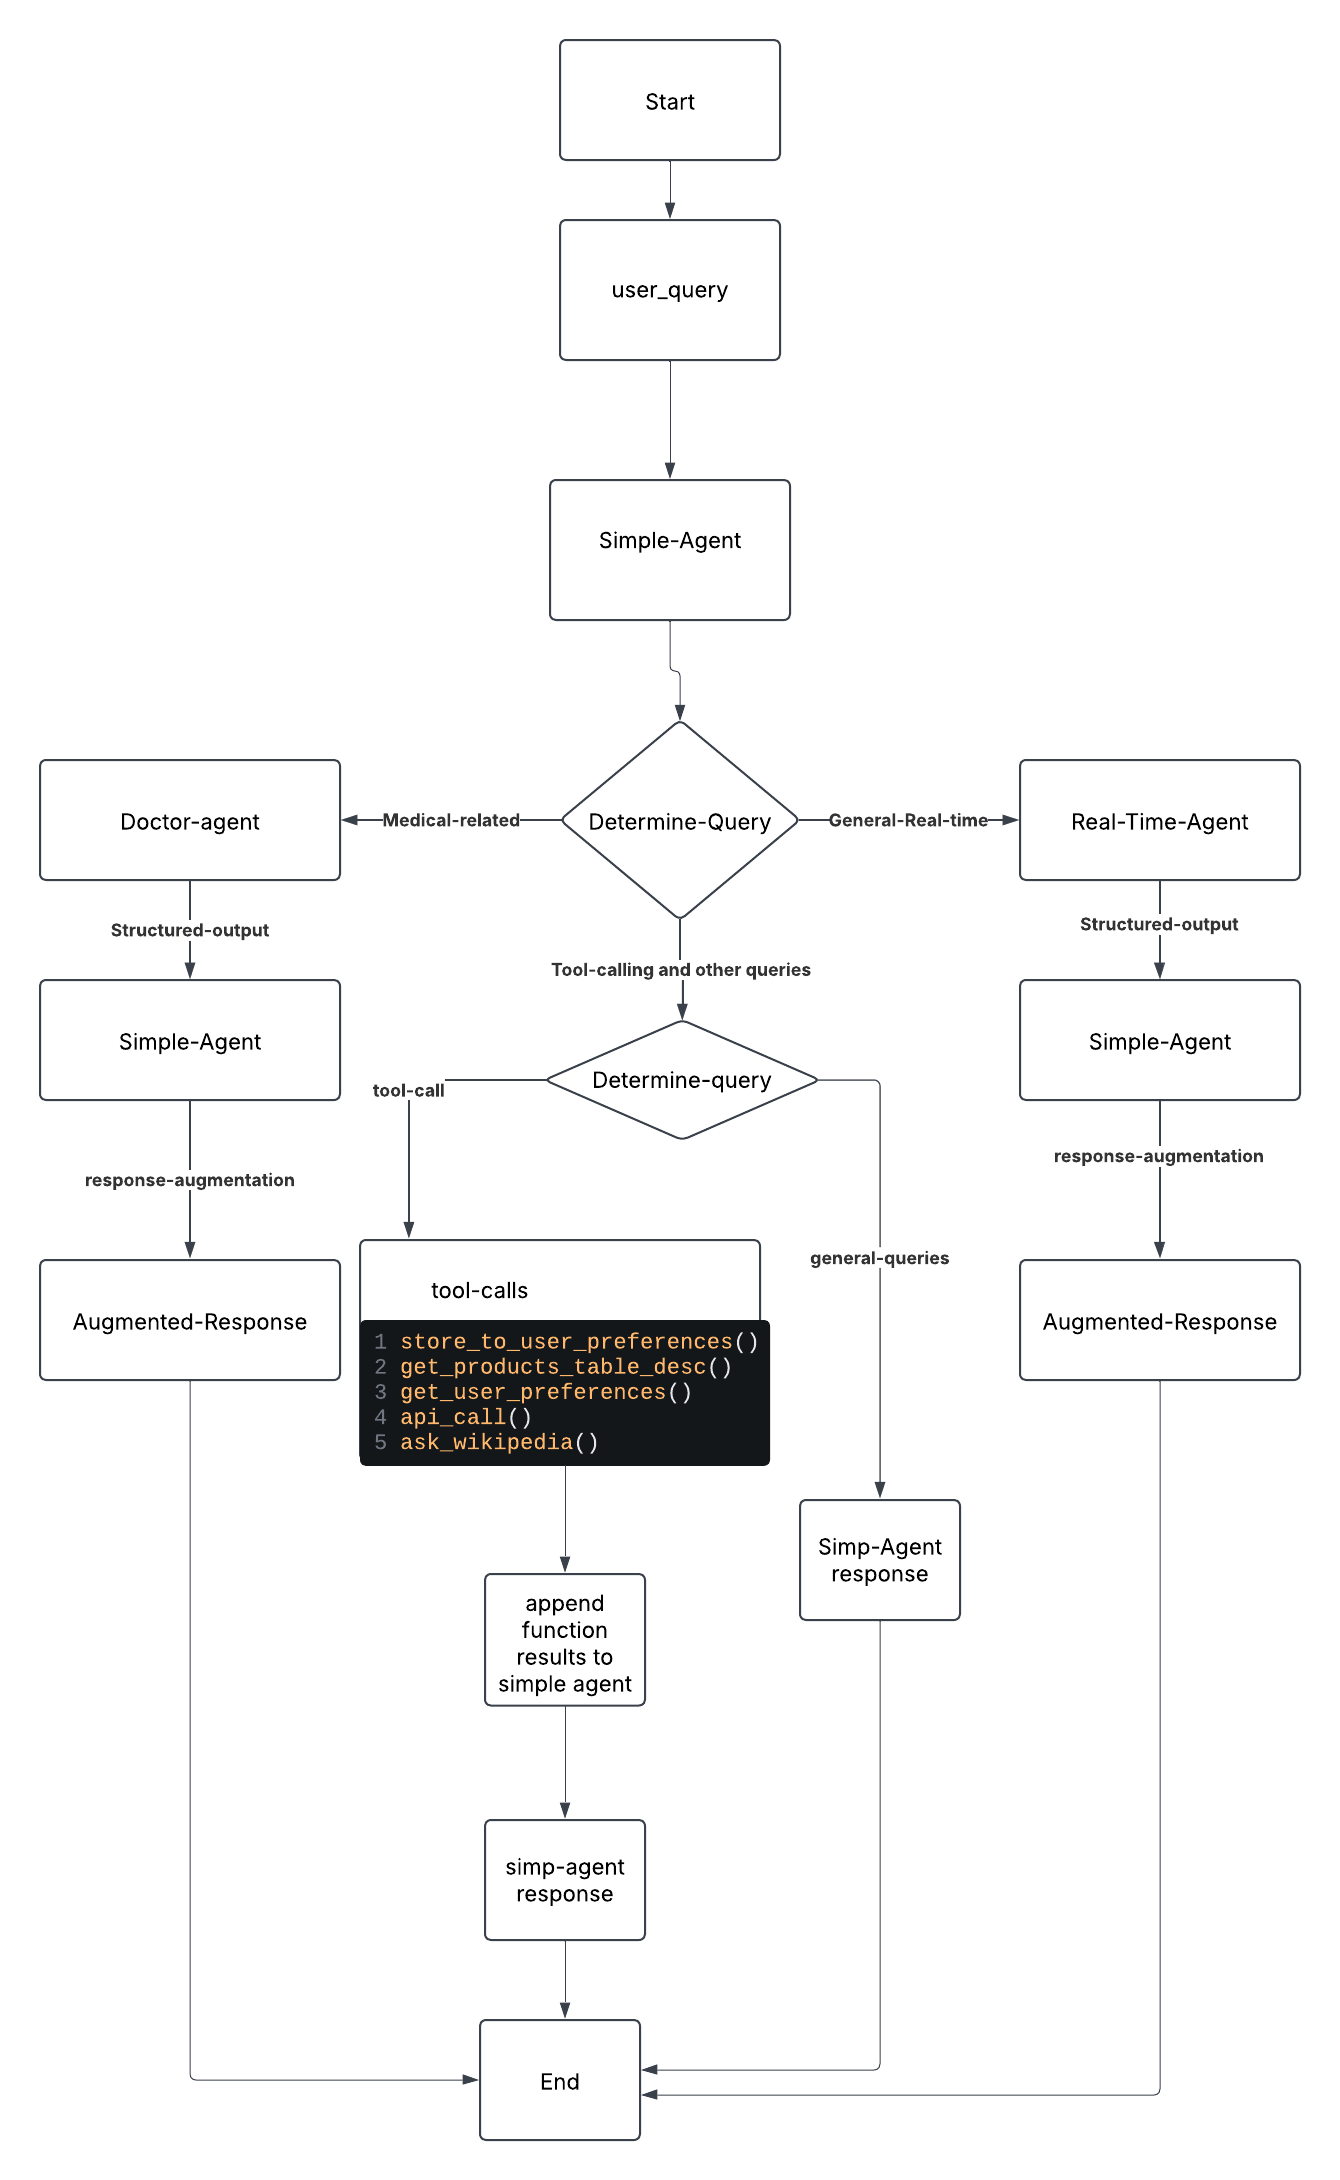

In [70]:
display(Image(filename="/kaggle/input/flowchart/Blank diagram.png"))

In [6]:
#TOOLS

def get_current_datetime_ist():
    """
    Returns the current date and time in IST as a formatted string.
    Example: 'April 05, 2025, 09:45 PM'
    """
    ist = pytz.timezone('Asia/Kolkata')
    now_ist = datetime.now(ist)
    return now_ist.strftime("%B %d, %Y, %I:%M %p")


storage: dict[str, str] = {}

def store_to_user_preferences(key: str, value: str) -> None:
    """
    Stores or updates a user preference.

    Args:
        key (str): The preference name (e.g., "name", "favorite color").
        value (str): The corresponding value.
    """
    #when model calls this function-> perform an actual db call to store the user details and enhance the user recommendation 
    storage[key] = value

def get_user_preferences() -> dict[str, str]:
    """
    Retrieves all stored user preferences.

    Returns:
        dict: All key-value pairs stored by the user.
    """
    return storage

    
def ask_wikipedia(query: str) -> str:
    """
    Fetches summary of a query from Wikipedia using LangChain.

    Args:
        query (str): Wikipedia search query.

    Returns:
        str: Summary from Wikipedia or empty string.
    """
    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wikipedia.run(query)

def ask_doctor(query: str):
    advice_schema = {
        "type": "object",
        "properties": {
            "response": {
                "type": "string",
                "description": "Detailed medical advice based on the patient's query."
            },
            "confidence": {
                "type": "integer",
                "minimum": 1,
                "maximum": 5,
                "description": "Confidence score (1 = unsure, 5 = very confident)"
            }
        },
        "required": ["response", "confidence"]
    }

    model_config = types.GenerateContentConfig(
        system_instruction=doctor_instructions,
        tool_config={"function_calling_config": {"mode": 'ANY', "allowed_function_names":["ask_google"]}},
        response_mime_type='application/json',
        response_schema=advice_schema
    )

    chat = client.chats.create(
        model="gemini-2.0-flash",
        config=model_config
    )
    response = chat.send_message(query)

    return response.parsed


def ask_google(query: str):
    """
    Uses the Gemini model with the Google Search tool to answer general queries.

    Args:
        query (str): The question or search term you want to ask.

    Returns:
        str: The textual response generated by the model using Google search data.
    """
        
    chat = client.chats.create(
        model="gemini-2.0-flash",
        config={
            "tools": [{"google_search": {}}],
        "system_instruction":google_agent_instructions
        },
    )
    response=chat.send_message(query)
    return response.text


*TOOLS LIST*

In [8]:
tools = [ask_wikipedia,ask_doctor,ask_google,get_user_preferences,store_to_user_preferences,get_current_datetime_ist]

In [9]:

class ChatWithGemini:
    def __init__(self, model="gemini-1.5-flash", top_p=0.95, temperature=1.0):
        self.model_id = model
        self.top_p = top_p
        self.temperature = temperature
        self.system_prompt = system_prompt

    def set_content_config(self):
        return types.GenerateContentConfig(
            top_p=self.top_p,
            temperature=self.temperature,
            tools=tools,
            system_instruction=system_prompt
        )

    def ask(self, query: str) -> str:
        chat=client.chats.create(
            model=self.model_id,
            config=self.set_content_config()
        )
        response = chat.send_message(query)
        return response.text

In [65]:
chat = ChatWithGemini(model="gemini-2.0-flash")
query="heyy yesterday its srh vs pbks ipl cricket match... it was fucking good"

#Example of querying without a document
response = chat.ask("whats the weather like today in hyderabad city")
print("Gemini says:", response)

print(100*'-')

doc_response=ask_doctor("My head is hurting and I feel dizzy.")
print(doc_response)
print()
response2 = chat.ask("My head is hurting and I feel dizzy.")
print("Gemini says:", response2)
print(100*'-')

response3 = chat.ask("Store my favourite city as Hyderabad.")
print("Gemini says:", response3)
print(100*'-')

response4 = chat.ask("What is my favourite city?")
print("Gemini says:", response4)
print(100*'-')

Gemini says: Okay, the weather in Hyderabad today, April 13, 2025, is expected to have a minimum temperature of around 26 degrees Celsius and a maximum temperature of 38 degrees Celsius. The temperature is predicted to hover around 33 degrees Celsius throughout the day, with a wind speed of approximately 7.92 kmph. The wind will move around 111 degrees with a gust speed of 10.81 kmph. Sunrise was at 6:01 AM, and sunset will be at 6:31 PM. Currently, the temperature is 37°c with 23% humidity and a UV index of 7.

----------------------------------------------------------------------------------------------------
{'confidence': 3, 'response': "A headache accompanied by dizziness can have various causes, ranging from mild to more serious. Potential causes include dehydration, low blood sugar, inner ear problems (vertigo), migraine, or a side effect of medication. Less common but more serious causes could be a stroke, head injury, or carbon monoxide poisoning. It's important to monitor you

In [61]:
get_user_preferences()

{'favourite city': 'Hyderabad'}

# RAG IMPLEMENTATION


* The ChatWithDocument class implements a simple Retrieval-Augmented Generation (RAG) flow.
*  It Loads and parses PDF documents.
*  Splits them into chunks for processing.
*  Converts the chunks into vector embeddings using a Gemini-based embedding function.
*  Stores them in a CHROMA vector database.
*  On user query, retrieves the most relevant chunks and passes them to a language model to generate context-aware responses.
*  Additionally, it comes preloaded with default sample documents for experimentation and quick testing of the flow.  



In [19]:
from chromadb import Documents, EmbeddingFunction, Embeddings
from google.api_core import retry
import chromadb
from google.genai import types
import fitz

In [52]:
class ChatWithDocument:
    def __init__(self,dataset_title=None,file_name=None):
        self.dataset_title=dataset_title
        self.file_name=file_name
        
    class GeminiEmbeddingFunction(EmbeddingFunction):
        # Specify whether to generate embeddings for documents, or queries
        document_mode = True
    
        def __call__(self, input: Documents) -> Embeddings:
            if self.document_mode:
                embedding_task = "retrieval_document"
            else:
                embedding_task = "retrieval_query"
    
            response = client.models.embed_content(
                model="models/text-embedding-004",
                contents=input,
                config=types.EmbedContentConfig(
                    task_type=embedding_task,
                ),
            )
            return [e.values for e in response.embeddings]

    def ask(self,query):
        if self.dataset_title and self.file_name:
            doc=fitz.open(f"/kaggle/input/{self.dataset_title}/{self.file_name}")
            documents = [page.get_text() for page in doc]

            DB_NAME = f"{self.file_name}DB"
            
            embed_fn = self.GeminiEmbeddingFunction()
            embed_fn.document_mode = True
            
            chroma_client = chromadb.Client()
            db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)
            
            db.add(documents=documents, ids=[str(i) for i in range(len(documents))])
            embed_fn.document_mode = False

            
            result = db.query(query_texts=[query], n_results=1)
            [all_passages] = result["documents"]
            query_oneline = query.replace("\n", " ")


            prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
            Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
            However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
            strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.
            
            QUESTION: {query_oneline}
            """
            
            # Add the retrieved documents to the prompt.
            for passage in all_passages:
                passage_oneline = passage.replace("\n", " ")
                prompt += f"PASSAGE: {passage_oneline}\n"

            answer = client.models.generate_content(
                model="gemini-2.0-flash",
                contents=prompt)
            return answer.text
            
        else:
            DOCUMENT1 = "Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air into the car. Heat: The car will blow warm air into the car. Defrost: The car will blow warm air onto the windshield to defrost it."
            DOCUMENT2 = 'Your Googlecar has a large touchscreen display that provides access to a variety of features, including navigation, entertainment, and climate control. To use the touchscreen display, simply touch the desired icon.  For example, you can touch the "Navigation" icon to get directions to your destination or touch the "Music" icon to play your favorite songs.'
            DOCUMENT3 = "Shifting Gears Your Googlecar has an automatic transmission. To shift gears, simply move the shift lever to the desired position.  Park: This position is used when you are parked. The wheels are locked and the car cannot move. Reverse: This position is used to back up. Neutral: This position is used when you are stopped at a light or in traffic. The car is not in gear and will not move unless you press the gas pedal. Drive: This position is used to drive forward. Low: This position is used for driving in snow or other slippery conditions."
            
            documents = [DOCUMENT1, DOCUMENT2, DOCUMENT3]

            DB_NAME = "googlecardb"
            
            embed_fn = self.GeminiEmbeddingFunction()
            embed_fn.document_mode = True
            
            chroma_client = chromadb.Client()
            db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)
            
            db.add(documents=documents, ids=[str(i) for i in range(len(documents))])
            embed_fn.document_mode = False

            
            result = db.query(query_texts=[query], n_results=1)
            [all_passages] = result["documents"]
            query_oneline = query.replace("\n", " ")


            prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
            Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
            However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
            strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.
            
            QUESTION: {query_oneline}
            """
            
            # Add the retrieved documents to the prompt.
            for passage in all_passages:
                passage_oneline = passage.replace("\n", " ")
                prompt += f"PASSAGE: {passage_oneline}\n"

            answer = client.models.generate_content(
                model="gemini-2.0-flash",
                contents=prompt)
            return answer.text

**RUN THE CODE BLOCK TO SEE THE DATASETS AND FILES PRESENT IN YOUR KAGGLE-INPUT FOLDER**

In [64]:
import os

base_path = "/kaggle/input"

for root, dirs, files in os.walk(base_path):
    print(f"Current directory: {root}")
    
    if dirs:
        print("Subdirectories:")
        for d in dirs:
            print(f"  - {d}")
    else:
        print("No subdirectories.")
    
    if files:
        print("Files:")
        for f in files:
            print(f"  - {f}")
    else:
        print("No files.")
    
    print("-" * 50)

Current directory: /kaggle/input
Subdirectories:
  - example
  - agent1
No files.
--------------------------------------------------
Current directory: /kaggle/input/example
No subdirectories.
Files:
  - SYLLABUS-CSM-EMSML.pdf
--------------------------------------------------
Current directory: /kaggle/input/agent1
No subdirectories.
Files:
  - 22365_19_Agents_v8.pdf
--------------------------------------------------


**The ChatWithDocument class enables simple RAG (Retrieval-Augmented Generation) by allowing users to query PDF documents through natural language.**

**Usage Steps:**

* Initialization:

chat = ChatWithDocument(dataset_title="agent1", file_name="22365_19_Agents_v8.pdf")
dataset_title: Folder name under /kaggle/input/.

file_name: PDF file inside that folder.

* Querying the Document:

response = chat.ask("Summarize the agent types discussed.")
print(response)
* Internally, the class:

Loads the specified PDF using PyMuPDF.

Extracts the text from all pages.

Uses an embedding-based vector store (Chroma) to index the text.

Retrieves relevant chunks based on the query.

Passes them to an LLM for generating answers.

* Defaults for Testing:

If no parameters are passed, it loads a default document for experimentation.

# Note:

* Ensure that all datasets and files used in this notebook are placed inside the `/kaggle/input/` directory.
  
* The code is designed to access files only from the `input` folder.
  
* If your files are located elsewhere, the program will throw a `FileNotFoundError`.

* Only pdf format is supported

In [57]:
#chat = ChatWithDocument(dataset_name,file_name)
#response=chat.ask(query)
#print(response)

chat = ChatWithDocument()
Markdown(chat.ask("summarize this topic"))


Okay, so basically, your Googlecar comes with a climate control system that lets you change the temperature and how the air flows inside the car. You can find all the controls like buttons and knobs on the center console. There's a knob for setting the temperature, another for controlling the airflow, and one more for adjusting the fan speed. Plus, there's a mode button where you can pick options like "Auto" for automatic adjustments, "Cool" for cold air, "Heat" for warm air, and "Defrost" to clear the windshield.
